In [1]:
import pandas as pd

gla = pd.read_csv('BSSdata/GlasgownextBSSData.csv', encoding="utf-8")
print(gla.shape)
gla.head(5)

C:\Users\Calum\AppData\Local\Temp\ipykernel_34040\3671856591.py:3: DtypeWarning: Columns (0: START LAT, 1: START LONG) have mixed types. Specify dtype option on import or set low_memory=False.
  gla = pd.read_csv('BSSdata/GlasgownextBSSData.csv', encoding="utf-8")


(1877091, 10)


,Start time,End time,Duration,Rental place,Return place,START LAT,START LONG,END LAT,END LONG,usmart_id
0,2020-12-18T21:06:00.000Z,2020-12-18T21:29:00.000Z,1407,Duke Street Railway Station,Cambridge Street - ELECTRIC,55.858222,-4.213473,55.865063,-4.260291,7070e6d5e57403840cff9ffdd2da00b6
1,2020-12-19T08:10:00.000Z,2020-12-19T08:19:00.000Z,549,Langside Hall - ELECTRIC,Bridge Street Subway - ELECTRIC,55.8316,-4.27841,55.852500,-4.258850,be9070d1a40ccd45471c0987d4f2181e
2,2020-12-19T08:18:00.000Z,2020-12-19T08:30:00.000Z,705,Springfield Quay 2,Gallery of Modern Art - ELECTRIC,55.854391,-4.274764,55.859700,-4.251950,2d5f9a0eb1bf3a8db8b0724506d04a32
3,2020-12-19T09:57:00.000Z,2020-12-19T10:03:00.000Z,357,Glasgow Green,Trongate,55.84945,-4.23375,55.856000,-4.244670,a44d231daca03c46103a963879affed3
4,2020-12-19T11:20:00.000Z,2020-12-19T11:31:00.000Z,643,Duke Street Railway Station,Bridgeton,55.858222,-4.213473,55.848900,-4.226820,9fb3709e68d8ccd23f3cf9a02b4db429


In [ ]:
for col in ['START LAT', 'START LONG', 'END LAT', 'END LONG']:
    gla[col] = pd.to_numeric(gla[col], errors='coerce')

print(gla[['START LAT','START LONG']].isna().sum())

START LAT     3
START LONG    3
dtype: int64


In [3]:

gla.dropna(subset=['START LAT','START LONG'], inplace=True)
print(gla[['START LAT','START LONG']].isna().sum())

START LAT     0
START LONG    0
dtype: int64


In [4]:
del gla['usmart_id']

In [5]:
print(gla.shape)

gla.head(5)

(1877088, 9)


,Start time,End time,Duration,Rental place,Return place,START LAT,START LONG,END LAT,END LONG
0,2020-12-18T21:06:00.000Z,2020-12-18T21:29:00.000Z,1407,Duke Street Railway Station,Cambridge Street - ELECTRIC,55.858222,-4.213473,55.865063,-4.260291
1,2020-12-19T08:10:00.000Z,2020-12-19T08:19:00.000Z,549,Langside Hall - ELECTRIC,Bridge Street Subway - ELECTRIC,55.831600,-4.278410,55.852500,-4.258850
2,2020-12-19T08:18:00.000Z,2020-12-19T08:30:00.000Z,705,Springfield Quay 2,Gallery of Modern Art - ELECTRIC,55.854391,-4.274764,55.859700,-4.251950
3,2020-12-19T09:57:00.000Z,2020-12-19T10:03:00.000Z,357,Glasgow Green,Trongate,55.849450,-4.233750,55.856000,-4.244670
4,2020-12-19T11:20:00.000Z,2020-12-19T11:31:00.000Z,643,Duke Street Railway Station,Bridgeton,55.858222,-4.213473,55.848900,-4.226820


### **Station Cleaning**

In [6]:
print("Glasgow Unique start station Names:  ", gla['Rental place'].nunique())
print("Glasgow Unique end station Names:    ", gla['Return place'].nunique())
print("-"*40)
print("Glasgow Unique start station lat:   ", gla['START LAT'].nunique())
print("Glasgow Unique end station lat:     ", gla['END LAT'].nunique())
print()
print("Glasgow Unique start station long:  ", gla['START LONG'].nunique())
print("Glasgow Unique end station long:    ", gla['END LONG'].nunique())

Glasgow Unique start station Names:   1958
Glasgow Unique end station Names:     3056
----------------------------------------
Glasgow Unique start station lat:    15199
Glasgow Unique end station lat:      20357

Glasgow Unique start station long:   17183
Glasgow Unique end station long:     22431


In [7]:
start_pts = gla[['START LAT', 'START LONG']].rename(columns={'START LAT': 'lat', 'START LONG': 'lon'})
end_pts = gla[['END LAT', 'END LONG']].rename(columns={'END LAT': 'lat', 'END LONG': 'lon'})
all_pts = pd.concat([start_pts, end_pts])

coord_counts = all_pts.value_counts()

print("Coordinate Pair Unique Values:")
print(f"Total unique coordinate pairs: {len(coord_counts)}")
print(f"Coordinate pairs appearing only once: {(coord_counts == 1).sum()}")
print(f"Top 10 most common:")
print(coord_counts.head(10))

Coordinate Pair Unique Values:
Total unique coordinate pairs: 26215
Coordinate pairs appearing only once: 9903
Top 10 most common:
lat        lon      
55.900000  -4.290000    94617
55.849450  -4.233750    87988
55.861550  -4.249400    84613
55.900000  -4.260000    68963
55.856600  -4.263520    59913
55.900000  -4.250000    58828
55.856800  -4.255290    53947
55.850554  -4.248127    51131
55.869700  -4.308460    49958
55.860633  -4.241900    44820
Name: count, dtype: int64


Plotting 9903 one-off coordinate pairs


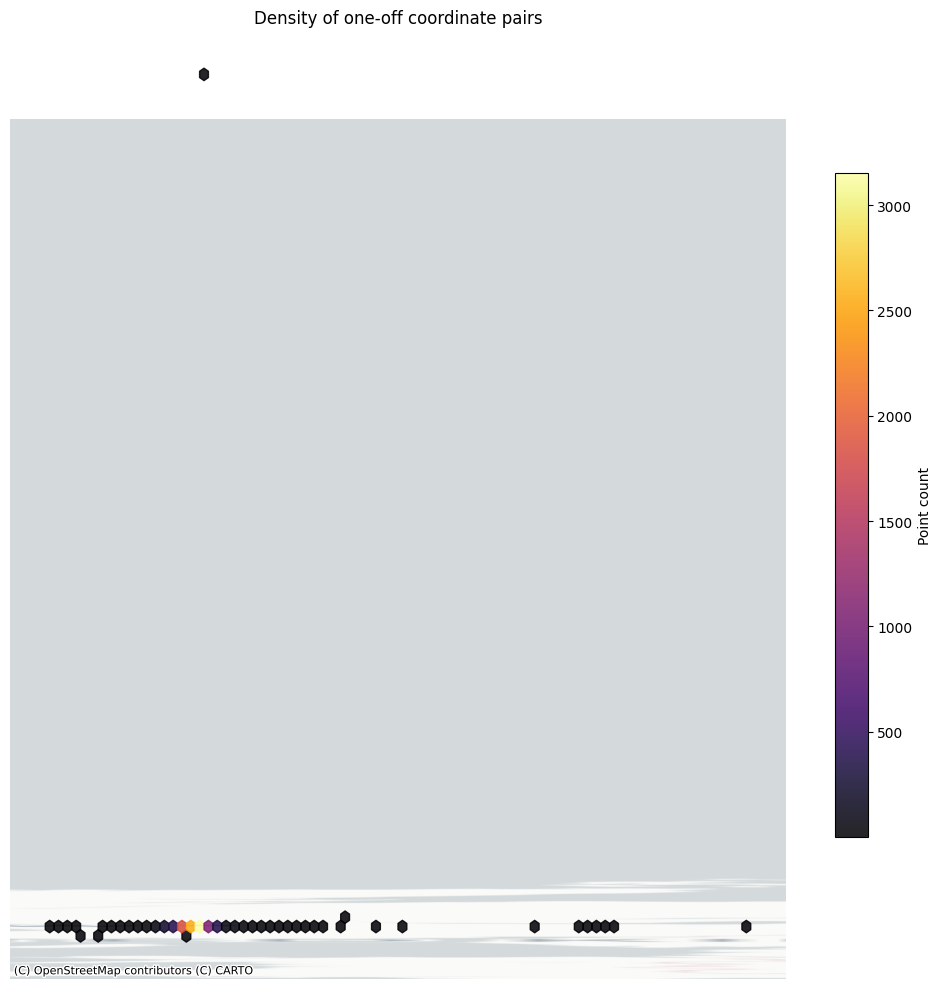

In [8]:
import matplotlib.pyplot as plt
import contextily as ctx
from pyproj import Transformer

one_off_coords = coord_counts[coord_counts == 1].index.to_frame(index=False)
print(f"Plotting {len(one_off_coords)} one-off coordinate pairs")

# contextily basemaps are in Web Mercator (EPSG:3857), your coords are lat/lon (EPSG:4326)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
x, y = transformer.transform(one_off_coords['lon'].values, one_off_coords['lat'].values)

# --- 1. Scatter of all points ---
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(x, y, s=8, color='#c0392b', alpha=0.5)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title(f"One-off coordinate pairs (n={len(one_off_coords)})")
plt.tight_layout()
plt.savefig("glasgow_one_off_coords_scatter.png", dpi=200)
plt.close()

# --- 2. Heatmap (hexbin — cheap and fine for large n) ---
fig, ax = plt.subplots(figsize=(10, 10))
hb = ax.hexbin(x, y, gridsize=80, cmap='inferno', mincnt=1, alpha=0.85)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("Density of one-off coordinate pairs")
fig.colorbar(hb, ax=ax, shrink=0.7, label='Point count')
plt.tight_layout()
plt.savefig("glasgow_one_off_coords_heatmap.png", dpi=200)
plt.show()

Removal of the coordinates that were both outside of Glasgow and the coordinates that had been rounded to two decimal places.

In [9]:
BBOX = dict(lat_min=55.75, lat_max=56.02, lon_min=-4.60, lon_max=-3.95)

def in_bbox(lat, lon):
    return lat.between(BBOX['lat_min'], BBOX['lat_max']) & lon.between(BBOX['lon_min'], BBOX['lon_max'])

start_inbox = in_bbox(gla['START LAT'], gla['START LONG'])
end_inbox = in_bbox(gla['END LAT'], gla['END LONG'])

def looks_rounded(x, dp=2):
    return round(x, dp) == x

# Flag rows where either the start or end coordinate is a suspiciously
# rounded (2dp-or-cleaner) value — confirmed above to span hundreds of
# distinct station names, so these cannot be trusted as real locations
start_bad = gla['START LAT'].apply(looks_rounded) | gla['START LONG'].apply(looks_rounded)
end_bad = gla['END LAT'].apply(looks_rounded) | gla['END LONG'].apply(looks_rounded)

bad_coords = (~start_inbox) | (~end_inbox) | start_bad | end_bad

print("Out of Glasgow bbox (start or end):", ((~start_inbox) | (~end_inbox)).sum())
print(f"Rows removed (rounded/placeholder coords on either end): {bad_coords.sum()}")
print(f"Rows remaining: {(~bad_coords).sum()} of {len(gla)}")

gla = gla[~bad_coords].reset_index(drop=True)

Out of Glasgow bbox (start or end): 666
Rows removed (rounded/placeholder coords on either end): 394738
Rows remaining: 1482350 of 1877088


In [10]:
start_pts = gla[['Rental place', 'START LAT', 'START LONG']].rename(columns={'Rental place': 'place',
                                                                             'START LAT': 'lat', 'START LONG': 'lon'})
end_pts = gla[['Return place', 'END LAT', 'END LONG']].rename(columns={'Return place': 'place', 
                                                                      'END LAT': 'lat', 'END LONG': 'lon'})
all_pts = pd.concat([start_pts, end_pts])

coord_counts = all_pts.value_counts()

print("Coordinate Pair Unique Values:")
print(f"Total unique coordinate pairs: {len(coord_counts)}")
print(f"Coordinate pairs appearing only once: {(coord_counts == 1).sum()}")

Coordinate Pair Unique Values:
Total unique coordinate pairs: 17297
Coordinate pairs appearing only once: 12237


In [11]:
place_coord_counts = all_pts.value_counts(['place', 'lat', 'lon'])
identified_stations = place_coord_counts[place_coord_counts > 10].reset_index()
identified_stations.columns = ['place', 'lat', 'lon', 'count']

print("Distinct (place, lat, lon) combinations:", len(place_coord_counts))
print("Identified stations (count > 10):", len(identified_stations))
print("Unique place names among identified stations:", identified_stations['place'].nunique())

dupe_names = identified_stations['place'].value_counts()
print("Place names with more than one qualifying coordinate:", (dupe_names > 1).sum())

# One-off coordinates: ignoring name, a coordinate pair appearing only once
coord_only_counts = all_pts[['lat', 'lon']].value_counts()
one_off_coords = coord_only_counts[coord_only_counts == 1].reset_index()
one_off_coords.columns = ['lat', 'lon', 'count']

print("One-off coordinate pairs:", len(one_off_coords))

Distinct (place, lat, lon) combinations: 17297
Identified stations (count > 10): 460
Unique place names among identified stations: 128
Place names with more than one qualifying coordinate: 108
One-off coordinate pairs: 12167


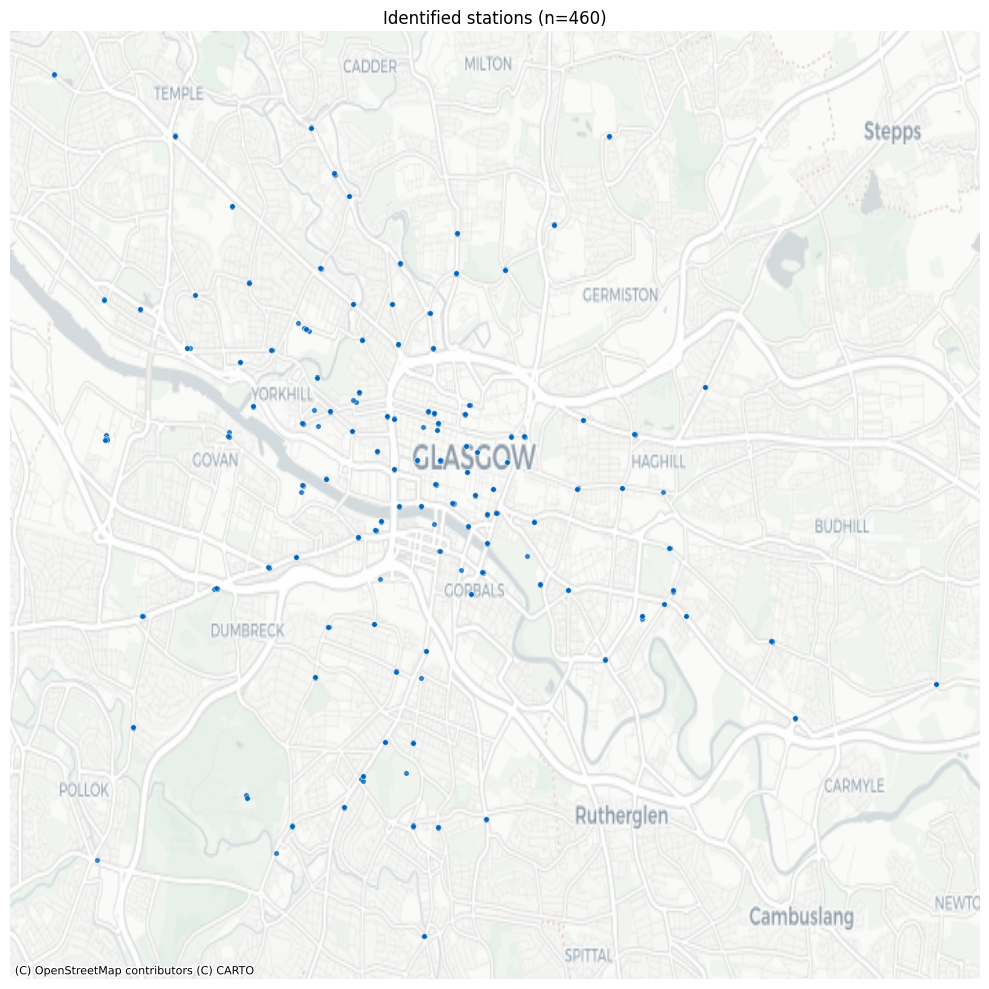

In [12]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
x, y = transformer.transform(identified_stations['lon'].values, identified_stations['lat'].values)

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(x, y, s=15, color='#0065bd', alpha=0.8, edgecolor='white', linewidth=0.3)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title(f"Identified stations (n={len(identified_stations)})")
plt.tight_layout()
plt.savefig("glasgow_identified_stations.png", dpi=200)
plt.show()

Identified issue that some stations are very closely clustered - station coordinates have drifted.

In [13]:
station_names = set(identified_stations['place'].unique())

both_station = gla['Rental place'].isin(station_names) & gla['Return place'].isin(station_names)
either_station = gla['Rental place'].isin(station_names) | gla['Return place'].isin(station_names)

print(f"Trips where BOTH start and end are identified stations: {both_station.sum()} ({both_station.mean()*100:.2f}%)")
print(f"Trips where AT LEAST ONE end is an identified station:  {either_station.sum()} ({either_station.mean()*100:.2f}%)")
print(f"Trips where NEITHER end is an identified station:       {(~either_station).sum()} ({(~either_station).mean()*100:.2f}%)")

Trips where BOTH start and end are identified stations: 1465208 (98.84%)
Trips where AT LEAST ONE end is an identified station:  1478548 (99.74%)
Trips where NEITHER end is an identified station:       3802 (0.26%)


In [14]:
named_stations = (identified_stations.sort_values('count', ascending=False)
                             .groupby('place', as_index=True)
                             .first()[['lat', 'lon', 'count']])

print("Number of named stations:", len(named_stations))
print(named_stations.head())

Number of named stations: 128
                                                          lat       lon  count
place                                                                         
(inoff) Clifton Place                               55.866102 -4.279717     51
132 Bath Street                                     55.864100 -4.259100   1457
Alexandra Parade (West) - ELECTRIC                  55.864466 -4.223158  17559
Alexandra Park (south entrance) Alexandra Parad...  55.863128 -4.210282  17175
Anderston Railway Station                           55.859900 -4.270100   1486


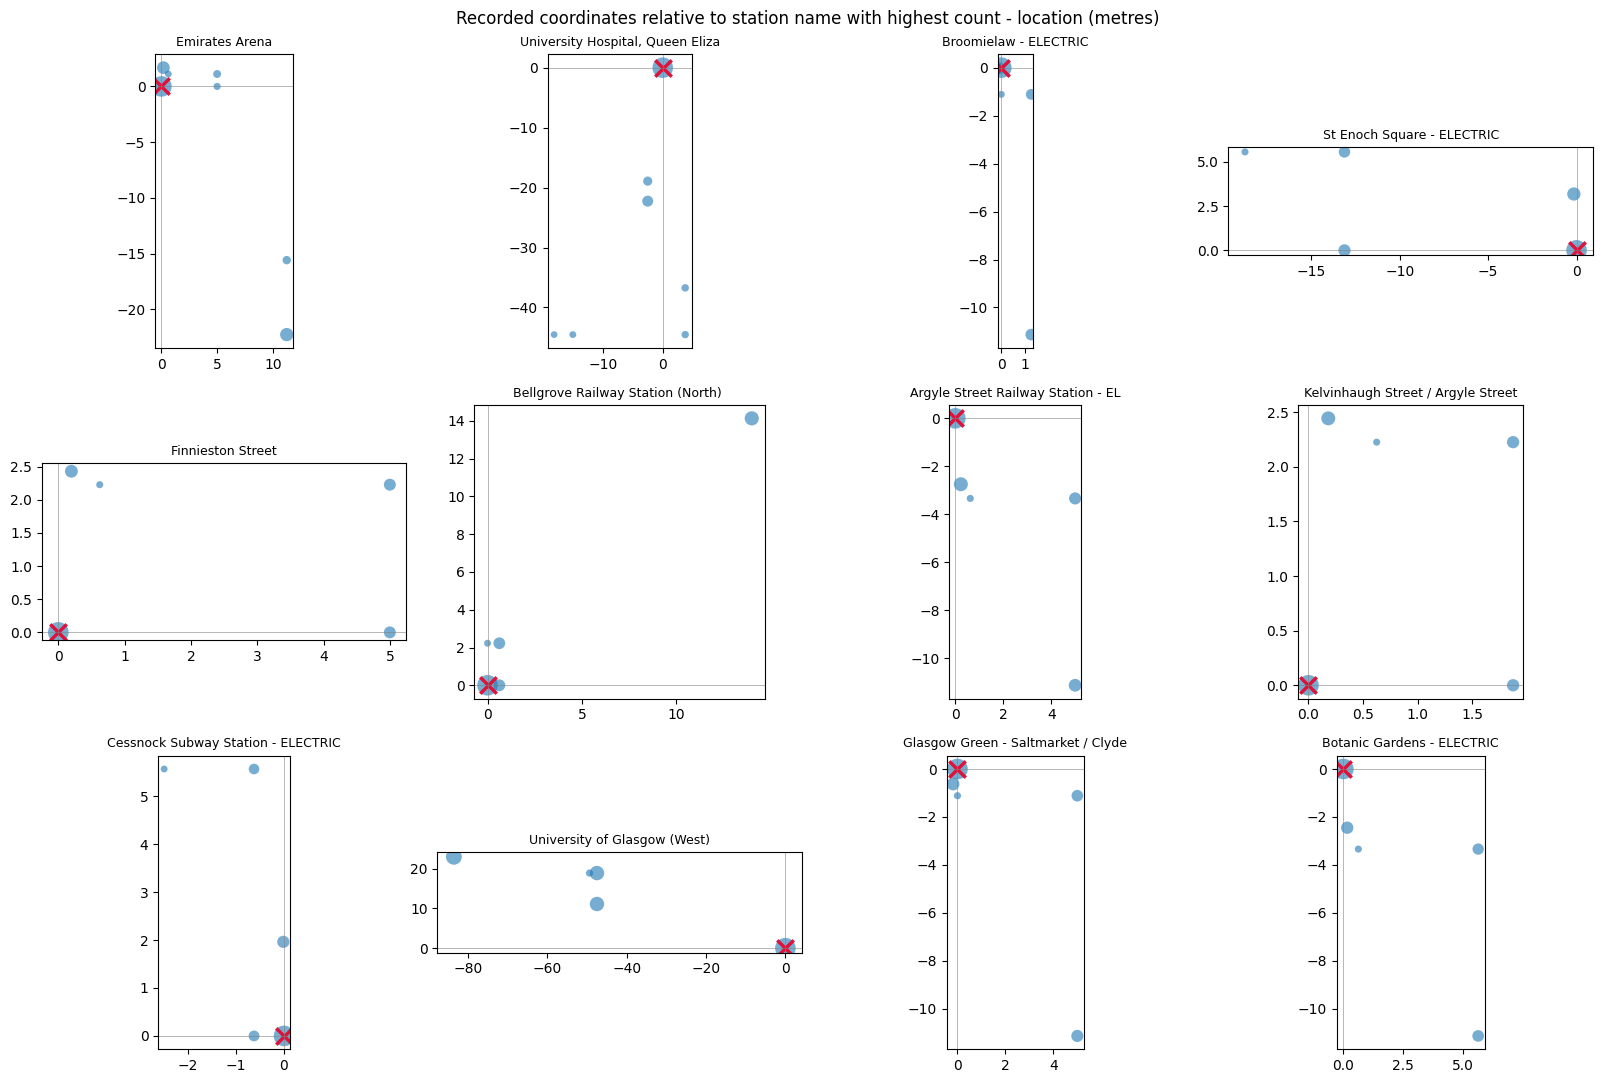

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# metres-per-degree longitude at Glasgow's latitude
mean_lat = gla['START LAT'].mean()
LON_M = np.cos(np.radians(mean_lat)) * 111_320


top = identified_stations['place'].value_counts().head(12).index

fig, axes = plt.subplots(3, 4, figsize=(16, 11))

for ax, st in zip(axes.ravel(), top):
    pts = identified_stations[identified_stations.place == st]
    ns = named_stations.loc[st]
    ax.scatter((pts.lon - ns.lon) * LON_M, (pts.lat - ns.lat) * 111_320,
               s=pts['count'] / pts['count'].max() * 200 + 20,  # size reflects how often each point was used
               alpha=0.6, edgecolor="none")
    ax.scatter(0, 0, marker="x", s=140, c="crimson", linewidths=2.5)
    ax.set_title(st[:34], fontsize=9)
    ax.axhline(0, lw=0.4, c="grey"); ax.axvline(0, lw=0.4, c="grey")
    ax.set_aspect("equal")

fig.suptitle("Recorded coordinates relative to station name with highest count - location (metres)")
fig.tight_layout()

The station coordinate drifts are all non significant (at most approximately 85 metres) at this the ridership levels would not be changed by if the station moved this much and it is most likely the station stayed in the same place however the coordinates changed slightly. 

In [16]:
station_names = set(identified_stations['place'].unique())

# canonical coordinate per station name (highest-count coordinate for that name)
canon = (identified_stations.sort_values('count', ascending=False)
                             .groupby('place', as_index=True)
                             .first()[['lat', 'lon']])

# keep only trips where BOTH start and end are identified stations
both_station = gla['Rental place'].isin(station_names) & gla['Return place'].isin(station_names)
gla_clean = gla[both_station].copy()

# attach canonical coordinates — this replaces the noisy raw GPS reading
# with the single agreed location for that named station
gla_clean['start_lat_canon'] = gla_clean['Rental place'].map(canon['lat'])
gla_clean['start_lon_canon'] = gla_clean['Rental place'].map(canon['lon'])
gla_clean['end_lat_canon']   = gla_clean['Return place'].map(canon['lat'])
gla_clean['end_lon_canon']   = gla_clean['Return place'].map(canon['lon'])

print(f"Trips retained: {len(gla_clean)} of {len(gla)} ({len(gla_clean)/len(gla)*100:.2f}%)")
print(f"Distinct stations in final dataset: {gla_clean['Rental place'].nunique()}")
print(gla_clean.shape)

Trips retained: 1465208 of 1482350 (98.84%)
Distinct stations in final dataset: 127
(1465208, 13)


In [17]:
gla_clean.head(5)

,Start time,End time,Duration,Rental place,Return place,START LAT,START LONG,END LAT,END LONG,start_lat_canon,start_lon_canon,end_lat_canon,end_lon_canon
0,2020-12-18T21:06:00.000Z,2020-12-18T21:29:00.000Z,1407,Duke Street Railway Station,Cambridge Street - ELECTRIC,55.858222,-4.213473,55.865063,-4.260291,55.858222,-4.213473,55.865063,-4.260291
1,2020-12-19T08:10:00.000Z,2020-12-19T08:19:00.000Z,549,Langside Hall - ELECTRIC,Bridge Street Subway - ELECTRIC,55.831600,-4.278410,55.852500,-4.258850,55.831600,-4.278410,55.852500,-4.258850
2,2020-12-19T08:18:00.000Z,2020-12-19T08:30:00.000Z,705,Springfield Quay 2,Gallery of Modern Art - ELECTRIC,55.854391,-4.274764,55.859700,-4.251950,55.854391,-4.274764,55.859700,-4.251950
3,2020-12-19T09:57:00.000Z,2020-12-19T10:03:00.000Z,357,Glasgow Green,Trongate,55.849450,-4.233750,55.856000,-4.244670,55.849450,-4.233750,55.856000,-4.244670
4,2020-12-19T11:20:00.000Z,2020-12-19T11:31:00.000Z,643,Duke Street Railway Station,Bridgeton,55.858222,-4.213473,55.848900,-4.226820,55.858222,-4.213473,55.848900,-4.226820


In [18]:
gla_clean = gla_clean.drop(['START LAT', 'START LONG', 'END LAT', 'END LONG'], axis=1)

gla_clean = (gla_clean[['Start time', 'End time', 'Duration', 'Rental place', 'Return place', 'start_lat_canon', 
                        'start_lon_canon', 'end_lat_canon', 'end_lon_canon']].rename(columns={
    'Start time': 'started_at', 'End time': 'ended_at', 'Rental place': 'origin', 'Return place': 'destination',
    'start_lat_canon' : 'start_lat', 'start_lon_canon' : 'start_lon', 'end_lat_canon' : 'end_lat',
    'end_lon_canon' : 'end_lon'
}))


Naming inconsistencies discovered manually through interactive map - where stations were clustered but had different names.
Dropping Workshop - discovered through interactive map.

In [19]:
# Manual station name merge — names referring to the same physical station
name_merge = {
    "Central Station": "Glasgow Central Station",
    "132 Bath Street": "Bath Street",
    "Shields Road (North)": "Sheilds Road", 
}
gla_clean['origin'] = gla_clean['origin'].replace(name_merge)
gla_clean['destination'] = gla_clean['destination'].replace(name_merge)

gla_clean = gla_clean[~gla_clean.isin(['Workshop - incoming (to process)']).any(axis=1)]

In [20]:
gla_clean.head(5)

,started_at,ended_at,Duration,origin,destination,start_lat,start_lon,end_lat,end_lon
0,2020-12-18T21:06:00.000Z,2020-12-18T21:29:00.000Z,1407,Duke Street Railway Station,Cambridge Street - ELECTRIC,55.858222,-4.213473,55.865063,-4.260291
1,2020-12-19T08:10:00.000Z,2020-12-19T08:19:00.000Z,549,Langside Hall - ELECTRIC,Bridge Street Subway - ELECTRIC,55.831600,-4.278410,55.852500,-4.258850
2,2020-12-19T08:18:00.000Z,2020-12-19T08:30:00.000Z,705,Springfield Quay 2,Gallery of Modern Art - ELECTRIC,55.854391,-4.274764,55.859700,-4.251950
3,2020-12-19T09:57:00.000Z,2020-12-19T10:03:00.000Z,357,Glasgow Green,Trongate,55.849450,-4.233750,55.856000,-4.244670
4,2020-12-19T11:20:00.000Z,2020-12-19T11:31:00.000Z,643,Duke Street Railway Station,Bridgeton,55.858222,-4.213473,55.848900,-4.226820


In [21]:
origin_stations = gla_clean[['origin', 'start_lat', 'start_lon']].rename(
    columns={'origin': 'place', 'start_lat': 'lat', 'start_lon': 'lon'}
)
destination_stations = gla_clean[['destination', 'end_lat', 'end_lon']].rename(
    columns={'destination': 'place', 'end_lat': 'lat', 'end_lon': 'lon'}
)

stations_df = pd.concat([origin_stations, destination_stations]).drop_duplicates().reset_index(drop=True)

print("Number of stations:", len(stations_df))
print(stations_df.head())

Number of stations: 127
                         place        lat       lon
0  Duke Street Railway Station  55.858222 -4.213473
1     Langside Hall - ELECTRIC  55.831600 -4.278410
2           Springfield Quay 2  55.854391 -4.274764
3                Glasgow Green  55.849450 -4.233750
4                 Carrick Quay  55.854760 -4.251640


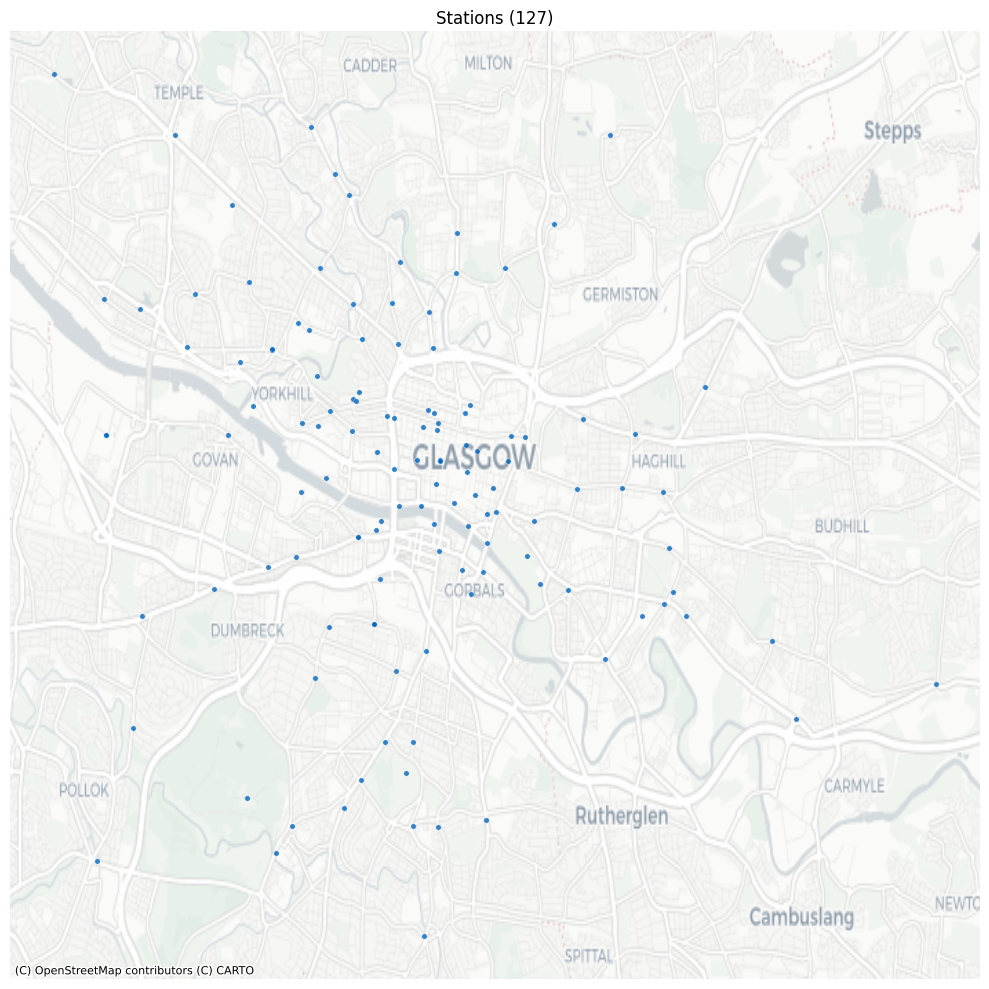

In [22]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
x, y = transformer.transform(stations_df['lon'].values, stations_df['lat'].values)

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(x, y, s=15, color='#0065bd', alpha=0.8, edgecolor='white', linewidth=0.3)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title(f"Stations ({len(stations_df)})")
plt.tight_layout()
plt.savefig("glasgow_stations.png", dpi=200)
plt.show()

### **Trip Data Cleaning**

                             station  days_active  span_days  activity_density
                 St Vincent Crescent            1          1             1.000
                               G37ld            5         31             0.161
Pollok Roundabout (Temporarily Shut)            5         14             0.357
               (inoff) Clifton Place            7         84             0.083
                    Clyde Place Quay           45        107             0.421
         Glasgow Kelvin College East           52        144             0.361
                   University Avenue           56        700             0.080
                        Sheilds Road           64        659             0.097
    Pollokshaws West Railway Station           71        146             0.486
                   Blythswood Square           79        151             0.523
                 Shields Road Subway          117        150             0.780
                     People's Palace          134   

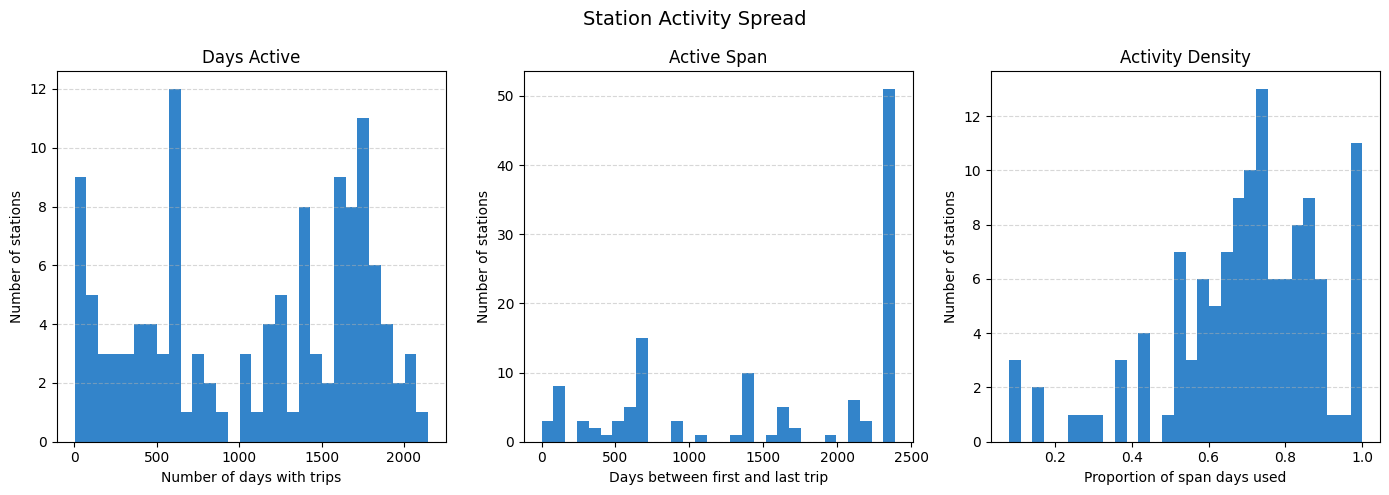


Summary statistics:
       days_active  span_days  activity_density
count      124.000    124.000           124.000
mean      1086.000   1552.702             0.694
std        650.682    871.158             0.203
min          1.000      1.000             0.080
25%        508.500    640.000             0.594
50%       1227.500   1714.000             0.717
75%       1686.000   2388.000             0.841
max       2147.000   2391.000             1.000


In [23]:
# --- Station activity: how many days each station was actually used ---
gla_clean['date'] = pd.to_datetime(gla_clean['started_at'], utc=True).dt.date

station_activity = (
    gla_clean.groupby('origin')['date']
    .agg(
        days_active='nunique',
        first_active='min',
        last_active='max'
    )
    .reset_index()
    .rename(columns={'origin': 'station'})
)

# Span in days between first and last trip (inclusive)
station_activity['span_days'] = (
    pd.to_datetime(station_activity['last_active']) -
    pd.to_datetime(station_activity['first_active'])
).dt.days + 1

# Activity density: proportion of days in span that had actual trips
station_activity['activity_density'] = (
    station_activity['days_active'] / station_activity['span_days']
).round(3)


print(station_activity.nsmallest(15, 'days_active')[['station', 'days_active', 'span_days', 'activity_density']]
      .to_string(index=False))

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].hist(station_activity['days_active'], bins=30, color='#0065bd', alpha=0.8)
axes[0].set_title('Days Active')
axes[0].set_xlabel('Number of days with trips')
axes[0].set_ylabel('Number of stations')

axes[1].hist(station_activity['span_days'], bins=30, color='#0065bd', alpha=0.8)
axes[1].set_title('Active Span')
axes[1].set_xlabel('Days between first and last trip')
axes[1].set_ylabel('Number of stations')

axes[2].hist(station_activity['activity_density'], bins=30, color='#0065bd', alpha=0.8)
axes[2].set_title('Activity Density')
axes[2].set_xlabel('Proportion of span days used')
axes[2].set_ylabel('Number of stations')

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Station Activity Spread', fontsize=14)
plt.tight_layout()
plt.savefig('glasgow_station_activity_spread.png', dpi=150)
plt.show()

# Summary stats
print("\nSummary statistics:")
print(station_activity[['days_active', 'span_days', 'activity_density']].describe().round(3))

Removing stations that were not active majority of time

In [24]:
gla_clean = gla_clean[~gla_clean.isin(['St Vincent Crescent', 'Pollok Roundabout (Temporarily Shut)',
                                       'G37ld', '(inoff) Clifton Place',  ]).any(axis=1)]

In [25]:
gla_clean["started_at"] = pd.to_datetime(gla_clean.started_at, errors="coerce")
gla_clean["ended_at"]   = pd.to_datetime(gla_clean.ended_at,   errors="coerce")

Duration summary (minutes):
count    1465028.0
mean          44.2
std          268.6
min            0.0
50%           13.4
90%           49.6
95%          102.3
99%          806.5
99.9%       3007.7
max        64458.1

Max duration: 1074.3 hours (44.8 days)
Trips over  1h:  120079 (8.20%)
Trips over  2h:   62458 (4.26%)
Trips over  4h:   32562 (2.22%)
Trips over 24h:    5482 (0.37%)


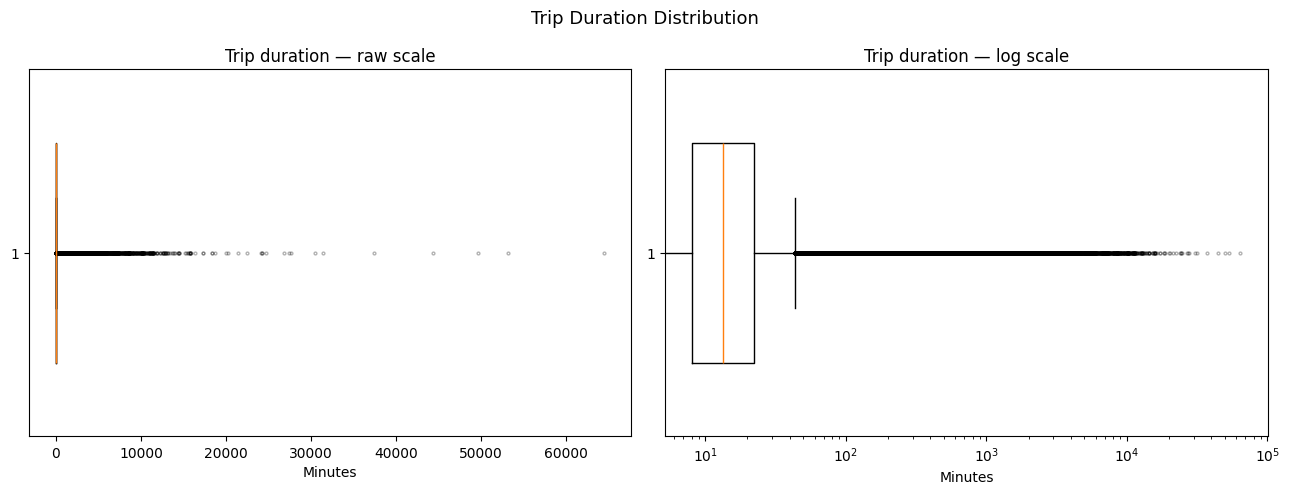

In [26]:
dur_min = gla_clean['Duration'] / 60

# --- Numbers you'll actually clean on ---
print("Duration summary (minutes):")
print(dur_min.describe(percentiles=[.5, .9, .95, .99, .999]).round(1).to_string())
print(f"\nMax duration: {gla_clean['Duration'].max()/3600:.1f} hours "
      f"({gla_clean['Duration'].max()/86400:.1f} days)")
for h in [1, 2, 4, 24]:
    over = (gla_clean['Duration'] > h*3600).sum()
    print(f"Trips over {h:>2}h: {over:>7} ({over/len(gla_clean):.2%})")

# --- Box plots: raw + log scale ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax in axes:
    ax.boxplot(dur_min, vert=False, widths=0.6,
               flierprops=dict(marker='o', markersize=2, alpha=0.3, color='#0065bd'))
    ax.set_xlabel('Minutes')
axes[0].set_title('Trip duration — raw scale')
axes[1].set_xscale('log')
axes[1].set_title('Trip duration — log scale')
plt.suptitle('Trip Duration Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('glasgow_duration_boxplot.png', dpi=150)
plt.show()

In [27]:
before = len(gla_clean)

# Keep trips between 90 seconds and 3 hours (inclusive)
gla_clean = gla_clean[gla_clean['Duration'].between(90, 3*3600)]

removed = before - len(gla_clean)
print(f"Removed {removed} of {before} trips ({removed/before:.2%}); {len(gla_clean)} remain")

Removed 98357 of 1465028 trips (6.71%); 1366671 remain


Duration summary (minutes):
count    1366671.0
mean          20.5
std           23.6
min            1.5
50%           13.5
90%           40.4
95%           66.1
99%          135.4
99.9%        174.0
max          180.0

Max duration: 3.0 hours (0.1 days)
Trips over  1h:   78332 (5.73%)
Trips over  2h:   20711 (1.52%)
Trips over  4h:       0 (0.00%)
Trips over 24h:       0 (0.00%)


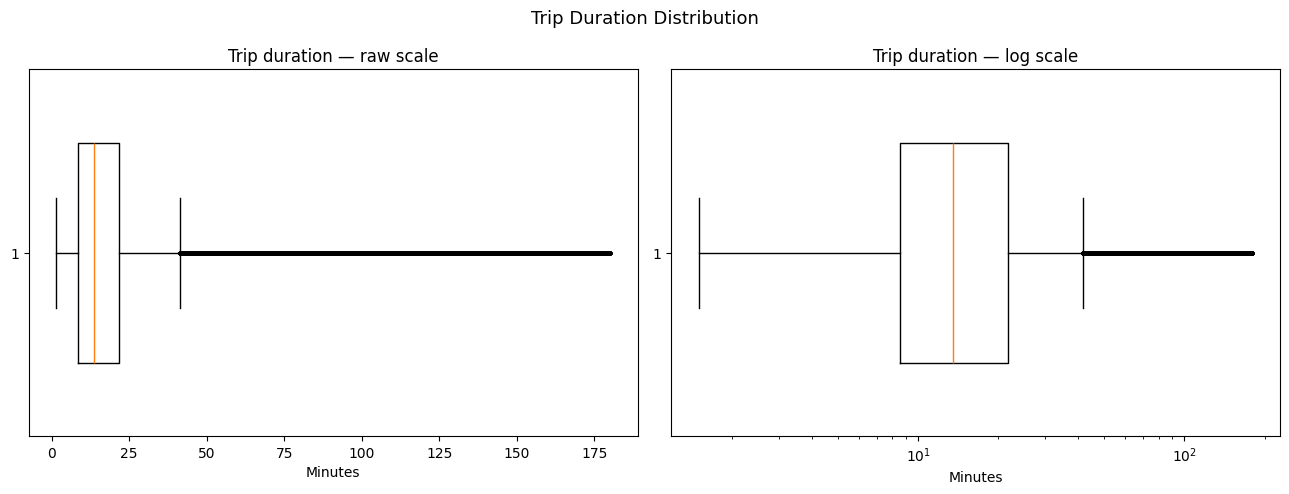

In [28]:
dur_min = gla_clean['Duration'] / 60

# --- Numbers you'll actually clean on ---
print("Duration summary (minutes):")
print(dur_min.describe(percentiles=[.5, .9, .95, .99, .999]).round(1).to_string())
print(f"\nMax duration: {gla_clean['Duration'].max()/3600:.1f} hours "
      f"({gla_clean['Duration'].max()/86400:.1f} days)")
for h in [1, 2, 4, 24]:
    over = (gla_clean['Duration'] > h*3600).sum()
    print(f"Trips over {h:>2}h: {over:>7} ({over/len(gla_clean):.2%})")

# --- Box plots: raw + log scale ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax in axes:
    ax.boxplot(dur_min, vert=False, widths=0.6,
               flierprops=dict(marker='o', markersize=2, alpha=0.3, color='#0065bd'))
    ax.set_xlabel('Minutes')
axes[0].set_title('Trip duration — raw scale')
axes[1].set_xscale('log')
axes[1].set_title('Trip duration — log scale')
plt.suptitle('Trip Duration Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('glasgow_duration_boxplot.png', dpi=150)
plt.show()

In [29]:
same = gla_clean['origin'] == gla_clean['destination']

print("Same-station trips:", same.sum(), f"({same.mean():.1%} of all trips)")
print("\nDuration (minutes) — same-station vs different-station:")
print(pd.concat([
    (gla_clean.loc[same, 'Duration'] / 60).describe().rename('same_station'),
    (gla_clean.loc[~same, 'Duration'] / 60).describe().rename('different'),
], axis=1).round(1))

# How many same-station trips are implausibly short (likely aborted/faulty)?
short = same & (gla_clean['Duration'] < 120)   # under 2 minutes
print(f"\nSame-station trips under 2 min (likely aborted): {short.sum()} "
      f"({short.sum()/same.sum():.1%} of same-station trips)")

Same-station trips: 164651 (12.0% of all trips)

Duration (minutes) — same-station vs different-station:
       same_station  different
count      164651.0  1202020.0
mean           35.9       18.4
std            39.9       19.4
min             1.5        1.5
25%             4.2        8.8
50%            21.8       13.3
75%            53.2       20.1
max           180.0      180.0

Same-station trips under 2 min (likely aborted): 15720 (9.5% of same-station trips)


In [30]:
gla_clean.to_csv('glaalltrips.csv', index=False)

### **Data Exploration**

Text(50.722222222222214, 0.5, 'Hour of day')

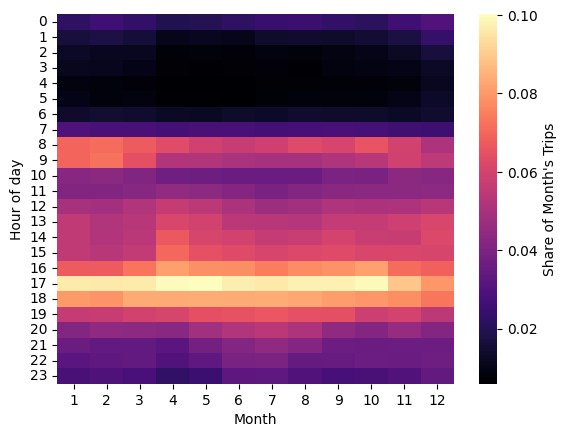

In [31]:
import seaborn as sns

piv = (gla_clean.assign(h=gla_clean.started_at.dt.hour, mo=gla_clean.started_at.dt.month)
            .pivot_table(index="h", columns="mo", aggfunc="size"))
piv = piv.div(piv.sum(axis=0), axis=1)   # normalise within month

sns.heatmap(piv, cmap="magma", cbar_kws={"label": "Share of Month's Trips"})
plt.xlabel("Month"); plt.ylabel("Hour of day")

In [32]:
gla_diff = gla_clean[gla_clean['origin'] != gla_clean['destination']].copy()
print(f"gla_diff: {len(gla_diff)} of {len(gla_clean)} trips "
      f"({len(gla_diff)/len(gla_clean):.1%} are between different stations)")

# --- 10 most common directed trips ---
top10 = (
    gla_diff.groupby(['origin', 'destination'])
    .size()
    .reset_index(name='trips')
    .sort_values('trips', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print(top10.to_string(index=False))
gla_diff.to_csv('glatrips.csv', index=False)

gla_diff: 1202020 of 1366671 trips (88.0% are between different stations)
                                               origin                                           destination  trips
                         University of Glasgow (West)                                   Partick Interchange   4707
                           St Enoch Square - ELECTRIC                                         Glasgow Green   3757
                                        Glasgow Green                            St Enoch Square - ELECTRIC   3649
                             George Square - ELECTRIC          Bellgrove Railway Station (North) - ELECTRIC   3622
         Bellgrove Railway Station (North) - ELECTRIC          University of Strathclyde (South) - ELECTRIC   3464
                           St Enoch Square - ELECTRIC City of Glasgow College (Riverside Campus) - ELECTRIC   3457
         Bellgrove Railway Station (North) - ELECTRIC                              George Square - ELECTRIC   3424
City o

In [33]:
first_time = gla_diff['started_at'].min()
last_time = gla_diff['started_at'].max()

print(f"First: {first_time}")
print(f"Last: {last_time}")

First: 2017-09-15 08:37:00+00:00
Last: 2024-04-01 01:52:00+00:00


In [34]:
stations_final = pd.concat([
    gla_clean[['origin', 'start_lat', 'start_lon']].rename(
        columns={'origin': 'station_id', 'start_lat': 'lat', 'start_lon': 'lon'}),
    gla_clean[['destination', 'end_lat', 'end_lon']].rename(
        columns={'destination': 'station_id', 'end_lat': 'lat', 'end_lon': 'lon'}),
]).drop_duplicates(subset='station_id').reset_index(drop=True)

print(f"Stations in final gla_clean: {len(stations_final)}")
stations_final.to_csv('glasgow_stations.csv', index=False)

Stations in final gla_clean: 121
